In [15]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
import matplotlib.dates as mdates

In [16]:
data = pd.read_csv('../data_processed/SG_nona.csv')
data['date'] = pd.to_datetime(data['date'])
# df.drop((""), axis=1, inplace=True)
print(data.dtypes)

date                           datetime64[us]
new_confirmed                         float64
new_deceased                          float64
new_tested                            float64
cumulative_confirmed                  float64
                                    ...      
minimum_temperature_celsius           float64
maximum_temperature_celsius           float64
rainfall_mm                           float64
dew_point                             float64
relative_humidity                     float64
Length: 502, dtype: object


In [23]:
def configure_axis(ax: Axes, df_name) -> None:

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.set_xlim(min(df_name["date"]), max(df_name["date"]))

    ax.tick_params(axis='x', labelrotation=45, labelsize = 7)
    ax.tick_params(axis='x', labelrotation=45, labelsize = 7)

    ax.grid(True)


def simple_static_stats_plot(df,columns, titles, y_labels, colors, figname=None):
    fig, axs = plt.subplots(2,1,figsize = (9,7))

    dates_range = (df['date'].min(), df['date'].max())
    for column_nr in range(len(columns)):
        ax = axs[column_nr]
        ax.set_title(f"{titles[column_nr]} from {dates_range[0].date()} to {dates_range[1].date()}",)
        ax.plot(df['date'], df[columns[column_nr]],color = colors[column_nr])
        ax.set_ylabel(y_labels[column_nr])
        ax.set_xlabel('Date')
        configure_axis(ax=axs[column_nr],df_name=df)

    fig.tight_layout()
    plt.show()
    if figname is not None:
        fig.savefig(figname)

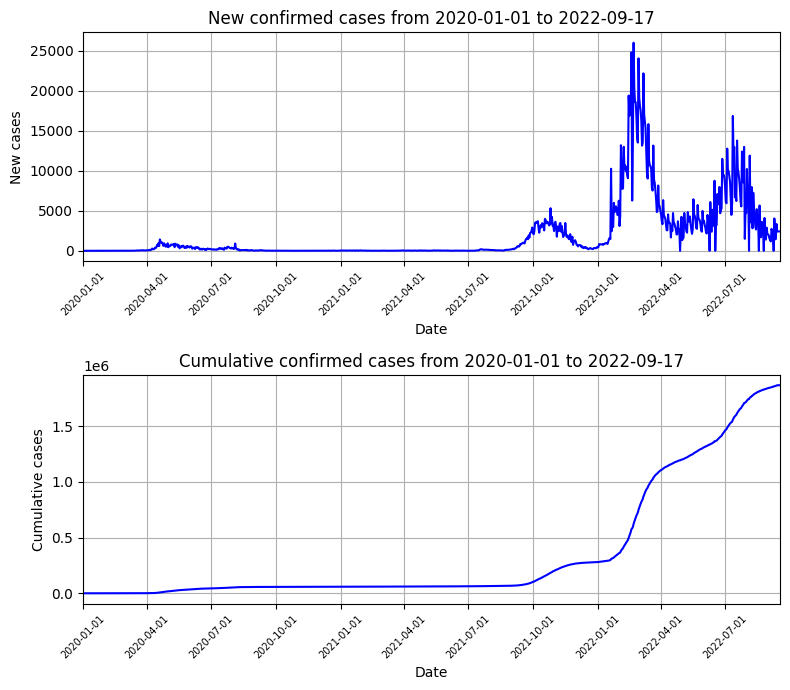

In [24]:
simple_static_stats_plot(data,
                              columns=("new_confirmed","cumulative_confirmed"),
                              titles=("New confirmed cases", "Cumulative confirmed cases"),
                              y_labels=("New cases", "Cumulative cases"),
                              colors=("blue","blue"),
                              figname="Cases"
                              )

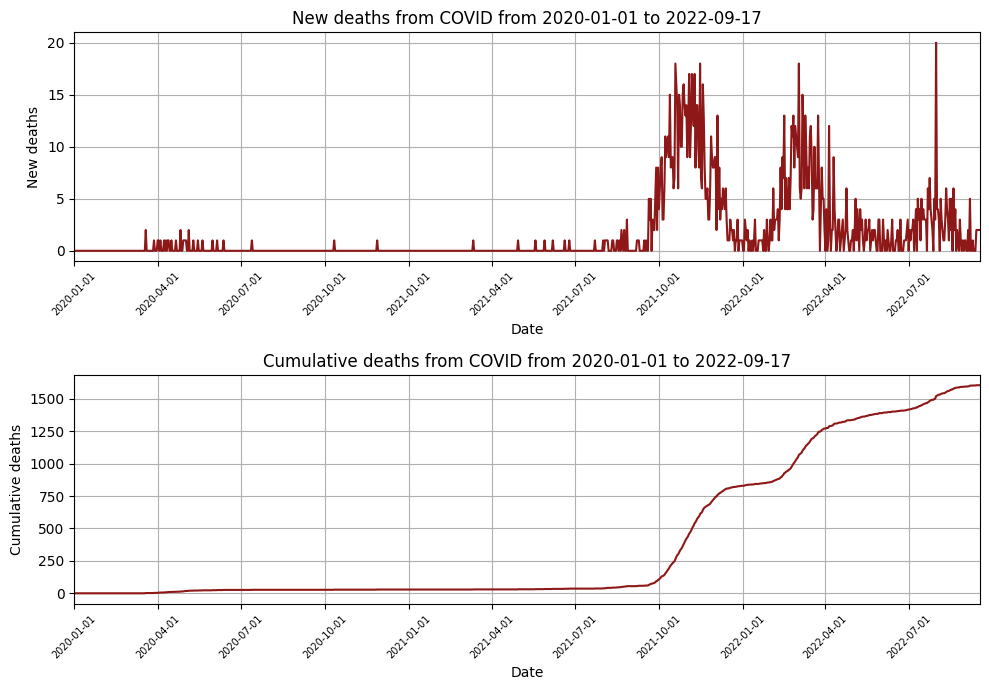

In [22]:
simple_static_stats_plot(data,
                              columns=("new_deceased","cumulative_deceased"),
                              titles=("New deaths from COVID", "Cumulative deaths from COVID"),
                              y_labels=("New deaths", "Cumulative deaths"),
                              colors=("#8E1717","#8E1717"),
                              figname="Deaths"
                              )

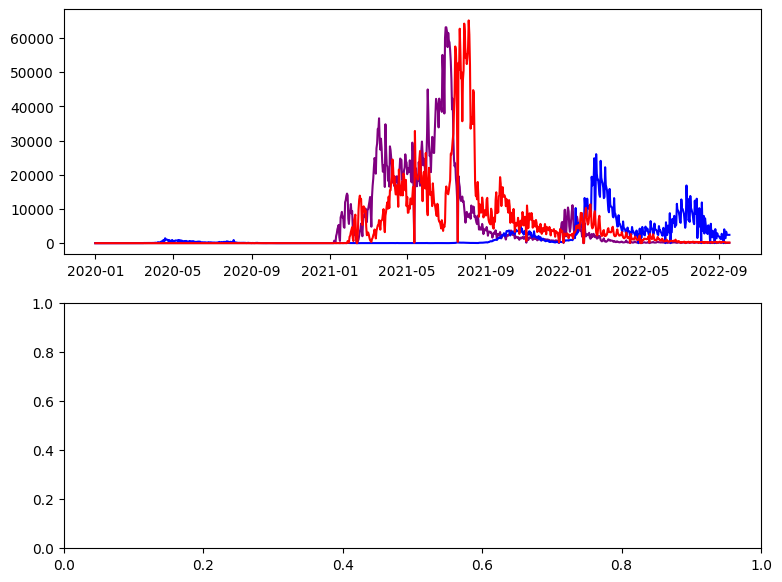

In [27]:
def vaccination_plot(df):
    fig, axs = plt.subplots(2,1,figsize = (9,7))

    axs[0].plot(df['date'], df['new_persons_vaccinated'], color = 'purple')
    axs[0].plot(df['date'], df["new_confirmed"], color = 'blue')
    axs[0].plot(df['date'], df['new_persons_fully_vaccinated'], color = 'red')

vaccination_plot(data)